<a href="https://colab.research.google.com/github/hamzaqarni1/DeepLearning/blob/main/Tutorial_10/Tutorial_10_UNet_Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 1. Import Libraries
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.optimizers import Adam
import numpy as np
import matplotlib.pyplot as plt
import cv2

print(f"TensorFlow Version: {tf.__version__}")

# 2. Create Synthetic Dataset (Images with random rectangles and their corresponding pixel masks)
def create_sample_data(img_size=128, num_samples=100):
    images = []
    masks = []

    np.random.seed(42) # Ensure reproducible results

    for _ in range(num_samples):
        # Initialize blank image and mask
        img = np.zeros((img_size, img_size, 3), dtype=np.uint8)
        mask = np.zeros((img_size, img_size, 1), dtype=np.uint8)

        # Generate random coordinates for a rectangle
        x1, y1 = np.random.randint(0, img_size // 2, 2)
        x2, y2 = x1 + np.random.randint(20, img_size // 2), y1 + np.random.randint(20, img_size // 2)

        # Draw white rectangle on image, and value 1 on mask
        cv2.rectangle(img, (x1, y1), (x2, y2), (255, 255, 255), -1)
        cv2.rectangle(mask, (x1, y1), (x2, y2), (1), -1)

        images.append(img)
        masks.append(mask)

    # Normalize images to [0, 1] range
    return np.array(images) / 255.0, np.array(masks)

# Generate and verify data
images, masks = create_sample_data()
print(f"Generated {len(images)} samples. Image shape: {images[0].shape}, Mask shape: {masks[0].shape}")

TensorFlow Version: 2.20.0
Generated 100 samples. Image shape: (128, 128, 3), Mask shape: (128, 128, 1)


In [3]:
def unet(input_size=(128, 128, 3)):
    inputs = layers.Input(input_size)

    # --- ENCODER (Downsampling) ---
    # Block 1
    c1 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D((2, 2))(c1)

    # Block 2
    c2 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D((2, 2))(c2)

    # --- BOTTLENECK ---
    c3 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(p2)
    c3 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(c3)

    # --- DECODER (Upsampling + Skip Connections) ---
    # Block 1 up
    u1 = layers.UpSampling2D((2, 2))(c3)
    u1 = layers.concatenate([u1, c2]) # Skip connection from Encoder Block 2
    c4 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(u1)
    c4 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(c4)

    # Block 2 up
    u2 = layers.UpSampling2D((2, 2))(c4)
    u2 = layers.concatenate([u2, c1]) # Skip connection from Encoder Block 1
    c5 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(u2)
    c5 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(c5)

    # Output Layer (1 channel with Sigmoid for binary pixel classification)
    outputs = layers.Conv2D(1, (1, 1), activation='sigmoid')(c5)

    return Model(inputs, outputs)

# Instantiate and compile the model
model = unet()
model.compile(optimizer=Adam(learning_rate=1e-4), loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │      1,792 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │     36,928 │ conv2d[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │    147,584 │ conv2d_2[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 32, 32,    │    590,080 │ conv2d_4[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 64, 64,    │          0 │ conv2d_5[0][0]    │
│ (UpSampling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 64, 64,    │          0 │ up_sampling2d[0]… │
│ (Concatenate)       │ 384)              │            │ conv2d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 64, 64,    │    442,496 │ concatenate[0][0] │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 64, 64,    │    147,584 │ conv2d_6[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_1     │ (None, 128, 128,  │          0 │ conv2d_7[0][0]    │
│ (UpSampling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 128, 128,  │          0 │ up_sampling2d_1[… │
│ (Concatenate)       │ 192)              │            │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 128, 128,  │    110,656 │ concatenate_1[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 128, 128,  │     36,928 │ conv2d_8[0][0]  

 Total params: 1,883,137 (7.18 MB)

 Trainable params: 1,883,137 (7.18 MB)

 Non-trainable params: 0 (0.00 B)

In [4]:
# Split data (80/20 split)
train_images, val_images = images[:80], images[80:]
train_masks, val_masks = masks[:80], masks[80:]

print("Training custom U-Net model...")
history = model.fit(
    train_images, train_masks,
    validation_data=(val_images, val_masks),
    batch_size=8,
    epochs=20,
    verbose=1
)

Training custom U-Net model...
Epoch 1/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 25s 845ms/step - accuracy: 0.9662 - loss: 0.6802 - val_accuracy: 0.9905 - val_loss: 0.6458
Epoch 2/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step - accuracy: 0.9937 - loss: 0.5441 - val_accuracy: 0.9940 - val_loss: 0.3208
Epoch 3/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step - accuracy: 0.9955 - loss: 0.1184 - val_accuracy: 0.9908 - val_loss: 0.0314
Epoch 4/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step - accuracy: 0.9955 - loss: 0.0160 - val_accuracy: 0.9980 - val_loss: 0.0096
Epoch 5/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step - accuracy: 0.9980 - loss: 0.0078 - val_accuracy: 0.9987 - val_loss: 0.0058
Epoch 6/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step - accuracy: 0.9989 - loss: 0.0048 - val_accuracy: 0.9990 - val_loss: 0.0040
Epoch 7/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step - accuracy: 0.9991 - loss: 0.0035 - val_accuracy: 0.9992 - val_loss: 0.0031
Epoch 8/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - accuracy: 0.9993 - loss: 


Final Validation Loss: 0.0008
Final Validation Accuracy: 99.97%

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 611ms/step
Visualizing segmentation performance...


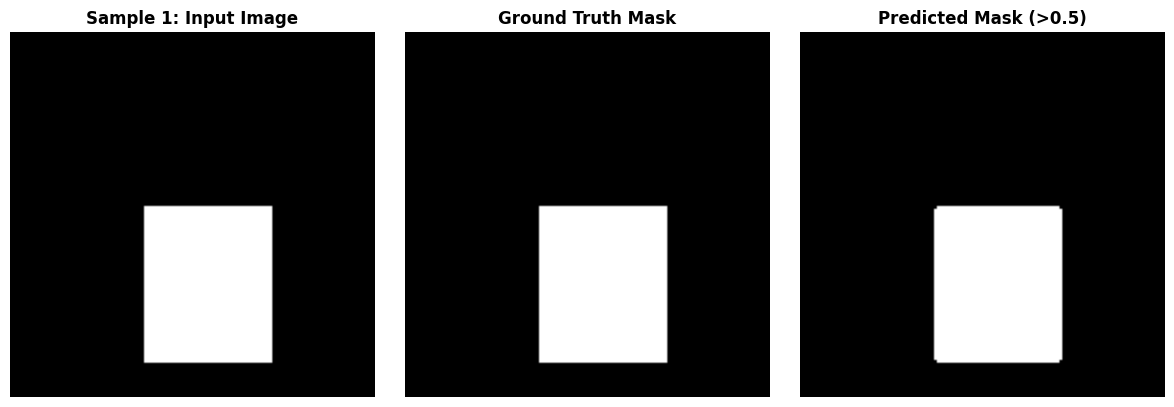

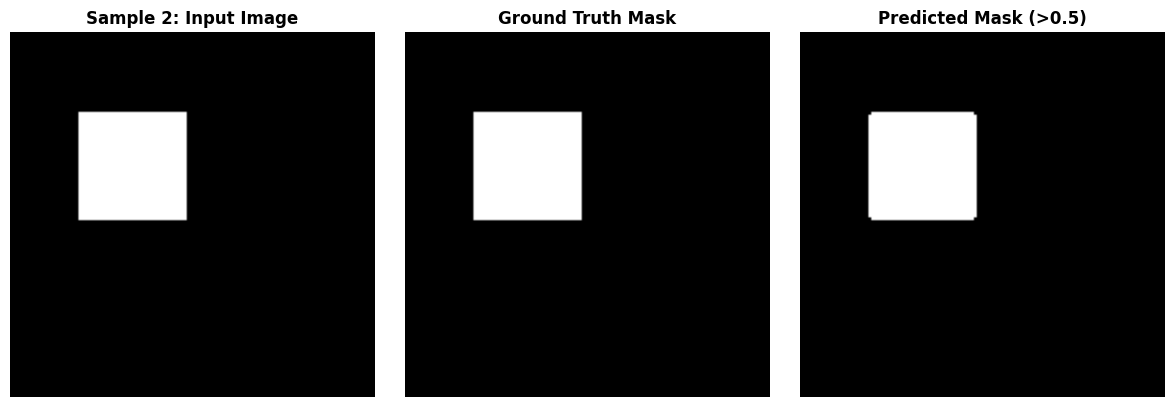

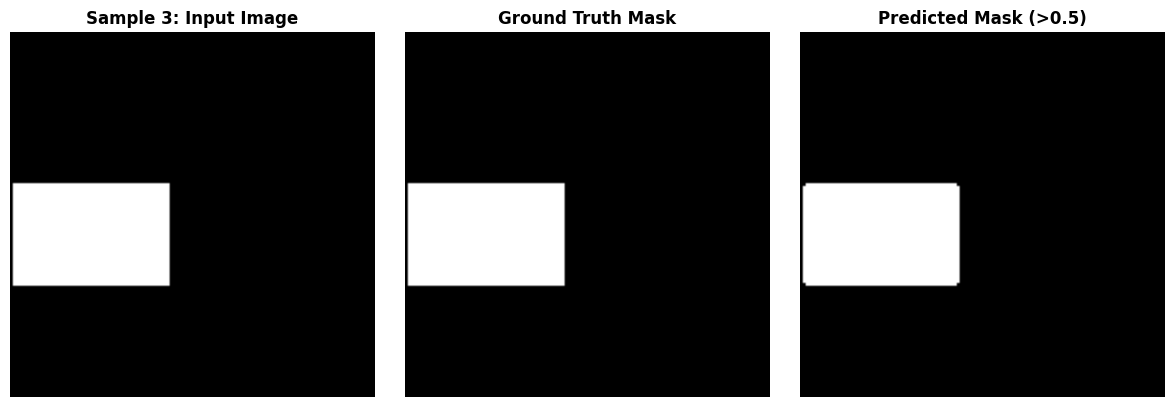

In [5]:
# 1. Evaluate Quantitative Metrics
loss, accuracy = model.evaluate(val_images, val_masks, verbose=0)
print(f"\nFinal Validation Loss: {loss:.4f}")
print(f"Final Validation Accuracy: {accuracy*100:.2f}%\n")

# 2. Predict on validation samples
pred_masks = model.predict(val_images)

# 3. Visualization Function
def plot_sample(image, true_mask, pred_mask, sample_idx):
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.title(f"Sample {sample_idx}: Input Image", fontweight='bold')
    plt.imshow(image)
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.title("Ground Truth Mask", fontweight='bold')
    plt.imshow(true_mask.squeeze(), cmap='gray')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.title("Predicted Mask (>0.5)", fontweight='bold')
    # Threshold probabilistic sigmoid outputs to binary mask
    binary_pred = (pred_mask.squeeze() > 0.5).astype(np.uint8)
    plt.imshow(binary_pred, cmap='gray')
    plt.axis('off')

    plt.tight_layout()
    plt.savefig(f'unet_prediction_sample_{sample_idx}.png', dpi=300)
    plt.show()

# Show first 3 validation results
print("Visualizing segmentation performance...")
for i in range(3):
    plot_sample(val_images[i], val_masks[i], pred_masks[i], sample_idx=i+1)

Task 1: Testing on Custom Data (Generalization)

Task 1: Custom dataset of circular shapes generated successfully!
Testing trained U-Net on unseen circular shapes...
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


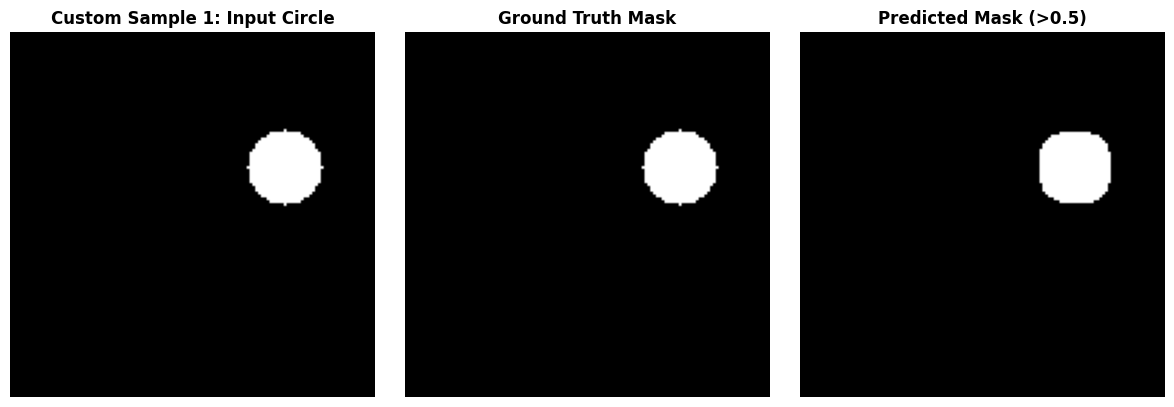

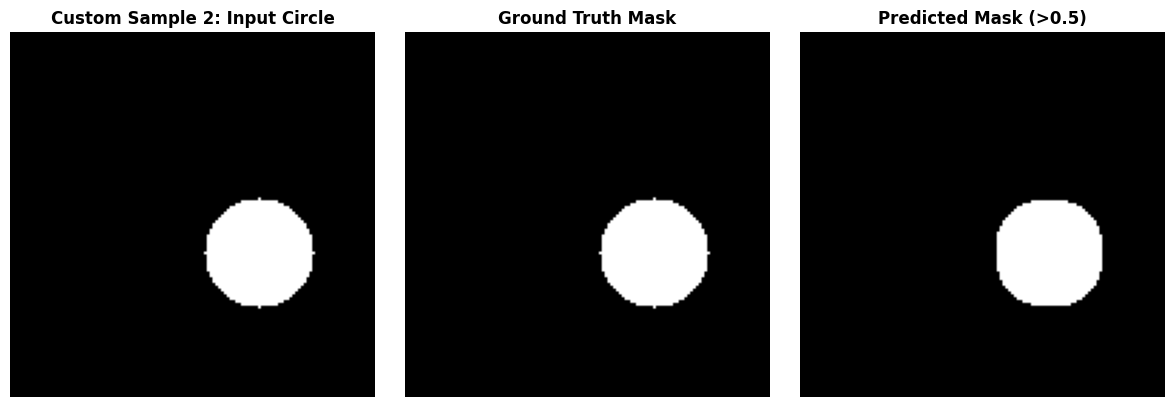

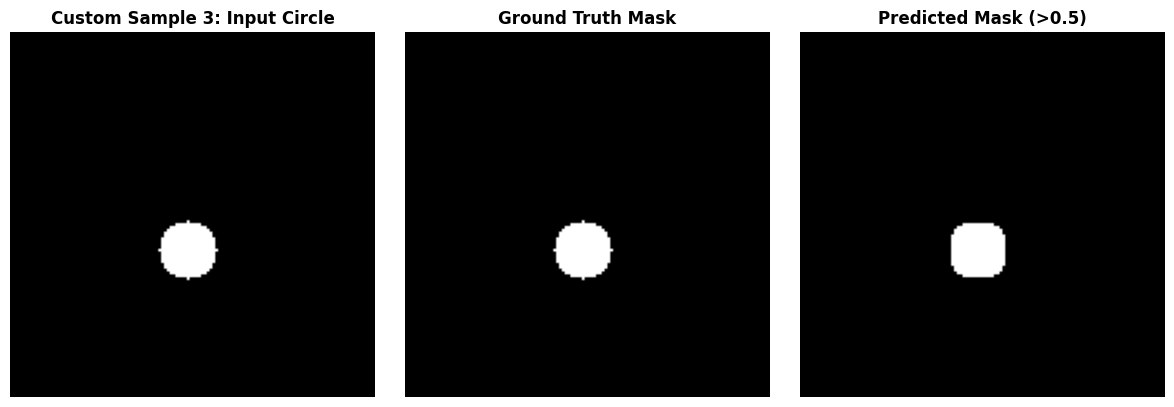

In [6]:
# --- TASK 1: Custom Dataset Generation & Testing ---
# Generating unseen shapes (circles) to test model generalization.

def create_custom_test_data(img_size=128, num_samples=5):
    custom_images = []
    custom_masks = []

    np.random.seed(123) # Ensure reproducible unique test shapes

    for _ in range(num_samples):
        img = np.zeros((img_size, img_size, 3), dtype=np.uint8)
        mask = np.zeros((img_size, img_size, 1), dtype=np.uint8)

        # Generate random coordinates and radius for a circular object
        center_x = np.random.randint(30, img_size - 30)
        center_y = np.random.randint(30, img_size - 30)
        radius = np.random.randint(10, 25)

        # Draw solid white circle on image, and binary 1 on mask
        cv2.circle(img, (center_x, center_y), radius, (255, 255, 255), -1)
        cv2.circle(mask, (center_x, center_y), radius, (1), -1)

        custom_images.append(img)
        custom_masks.append(mask)

    return np.array(custom_images) / 255.0, np.array(custom_masks)

# 1. Generate custom test data
custom_images, custom_masks = create_custom_test_data()
print("Task 1: Custom dataset of circular shapes generated successfully!")

# 2. Predict pixel masks using the trained U-Net
print("Testing trained U-Net on unseen circular shapes...")
custom_preds = model.predict(custom_images)

# 3. Plot and save generalization results
for i in range(3):
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.title(f"Custom Sample {i+1}: Input Circle", fontweight='bold')
    plt.imshow(custom_images[i])
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.title("Ground Truth Mask", fontweight='bold')
    plt.imshow(custom_masks[i].squeeze(), cmap='gray')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.title("Predicted Mask (>0.5)", fontweight='bold')
    # Apply binary thresholding to probabilistic outputs
    binary_pred = (custom_preds[i].squeeze() > 0.5).astype(np.uint8)
    plt.imshow(binary_pred, cmap='gray')
    plt.axis('off')

    plt.tight_layout()
    plt.savefig(f'task1_custom_shape_sample_{i+1}.png', dpi=300)
    plt.show()

Task 2: Modifying the Architecture (Adding Dropout)

In [7]:
# --- TASK 2: Architecture Modification (Adding Regularization) ---
# Injecting Dropout layers into the Encoder to prevent feature co-adaptation.

def unet_with_dropout(input_size=(128, 128, 3), dropout_rate=0.3):
    inputs = layers.Input(input_size)

    # --- ENCODER (With Dropout Regularization) ---
    # Block 1
    c1 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(c1)
    c1 = layers.Dropout(dropout_rate)(c1) # Task 2 Modification
    p1 = layers.MaxPooling2D((2, 2))(c1)

    # Block 2
    c2 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(c2)
    c2 = layers.Dropout(dropout_rate)(c2) # Task 2 Modification
    p2 = layers.MaxPooling2D((2, 2))(c2)

    # --- BOTTLENECK ---
    c3 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(p2)
    c3 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(c3)
    c3 = layers.Dropout(dropout_rate)(c3) # Task 2 Modification

    # --- DECODER ---
    u1 = layers.UpSampling2D((2, 2))(c3)
    u1 = layers.concatenate([u1, c2])
    c4 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(u1)
    c4 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(c4)

    u2 = layers.UpSampling2D((2, 2))(c4)
    u2 = layers.concatenate([u2, c1])
    c5 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(u2)
    c5 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(c5)

    outputs = layers.Conv2D(1, (1, 1), activation='sigmoid')(c5)

    return Model(inputs, outputs)

# Verify the modified architecture
regularized_model = unet_with_dropout()
regularized_model.compile(optimizer=Adam(learning_rate=1e-4), loss='binary_crossentropy', metrics=['accuracy'])
print("Task 2: Modified U-Net architecture with Dropout compiled successfully!")

Task 2: Modified U-Net architecture with Dropout compiled successfully!


Task 3: Learning Rate Hyperparameter Exploration

<>:20: SyntaxWarning: invalid escape sequence '\e'
<>:21: SyntaxWarning: invalid escape sequence '\e'
<>:20: SyntaxWarning: invalid escape sequence '\e'
<>:21: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_6424/1861909186.py:20: SyntaxWarning: invalid escape sequence '\e'
  plt.plot(range(1, 11), hist_fast.history['val_loss'], label='Aggressive ($\eta = 10^{-2}$)', color='red', marker='x', linewidth=2)
/tmp/ipykernel_6424/1861909186.py:21: SyntaxWarning: invalid escape sequence '\e'
  plt.plot(range(1, 11), hist_slow.history['val_loss'], label='Conservative ($\eta = 10^{-5}$)', color='blue', marker='o', linewidth=2)


Training model with aggressive learning rate (1e-2)...
Training model with conservative learning rate (1e-5)...


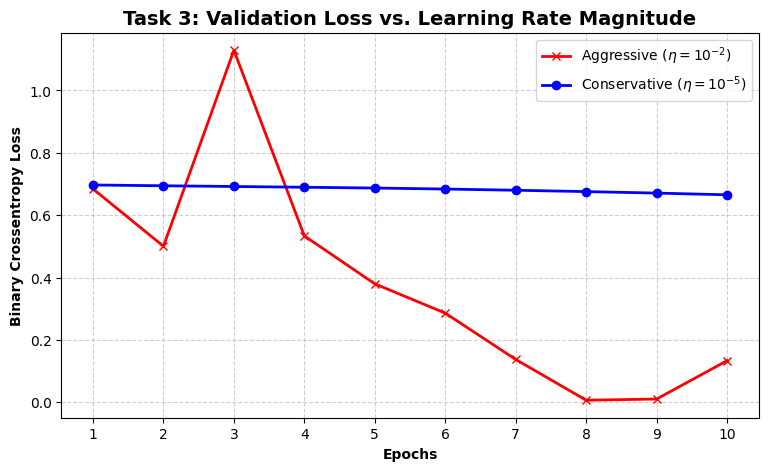

Task 3: Learning rate comparison plot saved successfully!


In [8]:
# --- TASK 3: Learning Rate Exploration & Visualization ---
# Comparing training stability across extreme learning rate choices.

# 1. Initialize two identical models for comparative training
model_fast = unet()
model_fast.compile(optimizer=Adam(learning_rate=1e-2), loss='binary_crossentropy') # Aggressive: 0.01

model_slow = unet()
model_slow.compile(optimizer=Adam(learning_rate=1e-5), loss='binary_crossentropy') # Conservative: 0.00001

# 2. Train both models quickly on a subset to observe initial trajectory
print("Training model with aggressive learning rate (1e-2)...")
hist_fast = model_fast.fit(train_images[:40], train_masks[:40], validation_data=(val_images[:10], val_masks[:10]), epochs=10, batch_size=8, verbose=0)

print("Training model with conservative learning rate (1e-5)...")
hist_slow = model_slow.fit(train_images[:40], train_masks[:40], validation_data=(val_images[:10], val_masks[:10]), epochs=10, batch_size=8, verbose=0)

# 3. Plot comparative validation loss curves
plt.figure(figsize=(9, 5))
plt.plot(range(1, 11), hist_fast.history['val_loss'], label='Aggressive ($\eta = 10^{-2}$)', color='red', marker='x', linewidth=2)
plt.plot(range(1, 11), hist_slow.history['val_loss'], label='Conservative ($\eta = 10^{-5}$)', color='blue', marker='o', linewidth=2)
# Optionally plot your base model's valid loss if stored, e.g., baseline 1e-4

plt.title("Task 3: Validation Loss vs. Learning Rate Magnitude", fontsize=14, fontweight='bold')
plt.xlabel("Epochs", fontweight='bold')
plt.ylabel("Binary Crossentropy Loss", fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper right')
plt.xticks(range(1, 11))

plt.savefig('task3_learning_rate_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("Task 3: Learning rate comparison plot saved successfully!")

Visualization & Download Code

In [9]:
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.optimizers import Adam
import numpy as np
import matplotlib.pyplot as plt
import cv2
from google.colab import files

# --- Set Seeds for Reproducibility ---
np.random.seed(42)
tf.random.set_seed(42)

# ==========================================
# 1. SYNTHETIC DATASET GENERATION
# ==========================================
def create_sample_data(img_size=128, num_samples=100):
    images, masks = [], []
    for _ in range(num_samples):
        img = np.zeros((img_size, img_size, 3), dtype=np.uint8)
        mask = np.zeros((img_size, img_size, 1), dtype=np.uint8)

        # Random rectangle coordinates
        x1, y1 = np.random.randint(0, img_size // 2, 2)
        x2, y2 = x1 + np.random.randint(20, img_size // 2), y1 + np.random.randint(20, img_size // 2)

        cv2.rectangle(img, (x1, y1), (x2, y2), (255, 255, 255), -1)
        cv2.rectangle(mask, (x1, y1), (x2, y2), (1), -1)

        images.append(img)
        masks.append(mask)
    return np.array(images) / 255.0, np.array(masks)

images, masks = create_sample_data()
train_images, val_images = images[:80], images[80:]
train_masks, val_masks = masks[:80], masks[80:]

# ==========================================
# 2. BASE U-NET ARCHITECTURE
# ==========================================
def unet(input_size=(128, 128, 3)):
    inputs = layers.Input(input_size)

    # Encoder
    c1 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D((2, 2))(c1)

    c2 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D((2, 2))(c2)

    # Bottleneck
    c3 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(p2)
    c3 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(c3)

    # Decoder
    u1 = layers.UpSampling2D((2, 2))(c3)
    u1 = layers.concatenate([u1, c2])
    c4 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(u1)
    c4 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(c4)

    u2 = layers.UpSampling2D((2, 2))(c4)
    u2 = layers.concatenate([u2, c1])
    c5 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(u2)
    c5 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(c5)

    outputs = layers.Conv2D(1, (1, 1), activation='sigmoid')(c5)
    return Model(inputs, outputs)

# Train Base Model
base_model = unet()
base_model.compile(optimizer=Adam(learning_rate=1e-4), loss='binary_crossentropy', metrics=['accuracy'])
base_history = base_model.fit(train_images, train_masks, validation_data=(val_images, val_masks), batch_size=8, epochs=20, verbose=0)

# Save Base Prediction Plot
pred_masks = base_model.predict(val_images[:1])
plt.figure(figsize=(10, 3))
plt.subplot(1, 3, 1); plt.title("Input Image"); plt.imshow(val_images[0]); plt.axis('off')
plt.subplot(1, 3, 2); plt.title("Ground Truth"); plt.imshow(val_masks[0].squeeze(), cmap='gray'); plt.axis('off')
plt.subplot(1, 3, 3); plt.title("Prediction (>0.5)"); plt.imshow((pred_masks[0].squeeze() > 0.5).astype(np.uint8), cmap='gray'); plt.axis('off')
plt.tight_layout()
plt.savefig('base_unet_prediction.png', dpi=300)
plt.close()
files.download('base_unet_prediction.png')

# ==========================================
# 3. TASK 1: CUSTOM DATASET (CIRCLES)
# ==========================================
def create_circle_data(img_size=128, num_samples=1):
    c_images, c_masks = [], []
    for _ in range(num_samples):
        img = np.zeros((img_size, img_size, 3), dtype=np.uint8)
        mask = np.zeros((img_size, img_size, 1), dtype=np.uint8)
        cx, cy = np.random.randint(30, img_size - 30, 2)
        r = np.random.randint(15, 25)
        cv2.circle(img, (cx, cy), r, (255, 255, 255), -1)
        cv2.circle(mask, (cx, cy), r, (1), -1)
        c_images.append(img); c_masks.append(mask)
    return np.array(c_images) / 255.0, np.array(c_masks)

circle_img, circle_mask = create_circle_data()
circle_pred = base_model.predict(circle_img)

plt.figure(figsize=(10, 3))
plt.subplot(1, 3, 1); plt.title("Custom Input (Circle)"); plt.imshow(circle_img[0]); plt.axis('off')
plt.subplot(1, 3, 2); plt.title("Ground Truth"); plt.imshow(circle_mask[0].squeeze(), cmap='gray'); plt.axis('off')
plt.subplot(1, 3, 3); plt.title("Generalization Output"); plt.imshow((circle_pred[0].squeeze() > 0.5).astype(np.uint8), cmap='gray'); plt.axis('off')
plt.tight_layout()
plt.savefig('task1_generalization.png', dpi=300)
plt.close()
files.download('task1_generalization.png')

# ==========================================
# 4. TASK 3: LEARNING RATE EXPLORATION
# ==========================================
model_fast = unet()
model_fast.compile(optimizer=Adam(learning_rate=1e-2), loss='binary_crossentropy')
hist_fast = model_fast.fit(train_images[:40], train_masks[:40], validation_data=(val_images[:10], val_masks[:10]), epochs=10, batch_size=8, verbose=0)

model_slow = unet()
model_slow.compile(optimizer=Adam(learning_rate=1e-5), loss='binary_crossentropy')
hist_slow = model_slow.fit(train_images[:40], train_masks[:40], validation_data=(val_images[:10], val_masks[:10]), epochs=10, batch_size=8, verbose=0)

plt.figure(figsize=(8, 4.5))
plt.plot(range(1, 11), hist_fast.history['val_loss'], label='Aggressive (η = 0.01)', color='red', marker='x', linewidth=2)
plt.plot(range(1, 11), base_history.history['val_loss'][:10], label='Optimal Base (η = 0.0001)', color='green', marker='s', linewidth=2)
plt.plot(range(1, 11), hist_slow.history['val_loss'], label='Conservative (η = 0.00001)', color='blue', marker='o', linewidth=2)
plt.title("Validation Loss Trajectories Across Learning Rates", fontweight='bold')
plt.xlabel("Epochs", fontweight='bold'); plt.ylabel("Binary Crossentropy Loss", fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.6); plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig('task3_learning_rates.png', dpi=300)
plt.close()
files.download('task3_learning_rates.png')

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>